QAに関して、モデルを製作していく

In [1]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import AutoModelForQuestionAnswering, TrainingArguments, Trainer
from transformers import DefaultDataCollator

I0000 00:00:1781751800.521769   64653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781751800.598592   64653 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781751801.357306   64653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
from datasets import load_dataset

# JGLUEベンチマークの中から、JSQuAD（QAタスク）を指定してロード
dataset = load_dataset("shunk031/JGLUE", name="JSQuAD")

# 中身の構造を確認
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'is_impossible'],
        num_rows: 62859
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'is_impossible'],
        num_rows: 4442
    })
})


In [3]:
dataset['train'][0]

{'id': 'a1000888p0q0',
 'title': '造語',
 'context': '造語 [SEP] 造語（ぞうご）は、新たに語（単語）を造ることや、既存の語を組み合わせて新たな意味の語を造ること、また、そうして造られた語である。新たに造られた語については、新語または新造語とも呼ばれる。',
 'question': '新たに語（単語）を造ることや、既存の語を組み合わせて新たな意味の語を造ること',
 'answers': {'text': ['造語'], 'answer_start': [0]},
 'is_impossible': False}

文章の長さの把握をする

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

文章の長さをみてもそこまで長くはない

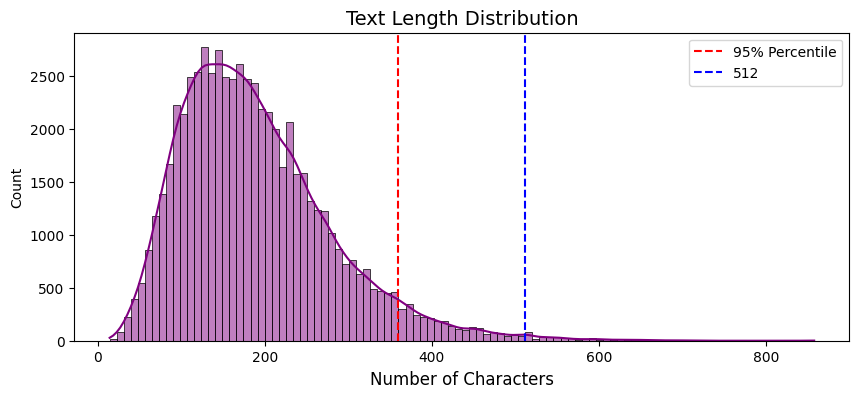

In [5]:
df_train = dataset["train"].to_pandas()
df_train['text_length']= df_train["context"].apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(df_train['text_length'], bins=100, kde=True, color="purple")
plt.title("Text Length Distribution", fontsize=14)
plt.xlabel("Number of Characters", fontsize=12)
plt.axvline(df_train['text_length'].quantile(0.95), color='red', linestyle='--', label='95% Percentile')
plt.axvline(512, color='blue', linestyle='--', label='512')
plt.legend()
plt.show()

In [6]:
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)


スライディングウィンドウについて、便利な関数があるのでそれを利用していく
窓に対してトークン化された文章に対して、実際のトークンでの回答の位置を抽出している

In [7]:
def prepare_train_features(examples):
    questions = [q.strip() for q in examples["question"]]#無駄なトークンの処理
    
    tokenized_examples = tokenizer(
        questions,
        examples["context"],#内部では、[cls]質問[sep]分客[sep]
        truncation="only_second",#削るのは文脈のみ
        max_length=384,
        stride=128,#かぶらせる数
        return_overflowing_tokens=True,#切った部分は必ず増殖
        return_offsets_mapping=True,  #元の文章での何番目にあたるのかの位置を保存
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")#文章が本来の文章の何番目にあるのかの保存 1,2,3を分割 1,1,2,3のように
    offset_mapping = tokenized_examples.pop("offset_mapping")#元の文章の何文字目から何文字目なのかを保存 popは、元の辞書も消す

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        input_ids = tokenized_examples["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id)#0を取得
        sample_index = sample_mapping[i]
        
        answers = examples["answers"][sample_index]

        if len(answers["answer_start"]) == 0:
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            start_char = answers["answer_start"][0]#スタートを取得,ちなみにanswerは{"text": ["東京"],"answer_start": [9], }このような形
            end_char = start_char + len(answers["text"][0])#

            sequence_ids = tokenized_examples.sequence_ids(i)#文章のIndexにおいて、none,0(質問),1(回答)のように振り分け、トークンの正解での位置

            idx = 0
            while sequence_ids[idx] != 1:
                idx += 1
            context_start = idx #文章のはじめのトークンの位置　例でいえば7
            
            idx = len(sequence_ids) - 1
            while sequence_ids[idx] != 1:
                idx -= 1
            context_end = idx #文章の終わりのトークンの位置を取得 例でいえば19

            if not (offsets[context_start][0] <= start_char and offsets[context_end][1] >= end_char):#トークンの世界での位置を取得し、
                start_positions.append(cls_index)
                end_positions.append(cls_index)
            else:
                token_start_index = context_start
                while token_start_index <= context_end and offsets[token_start_index][0] <= start_char:
                    token_start_index += 1
                start_positions.append(token_start_index - 1)

                token_end_index = context_end
                while token_end_index >= context_start and offsets[token_end_index][1] >= end_char:
                    token_end_index -= 1
                end_positions.append(token_end_index + 1)

    tokenized_examples["start_positions"] = start_positions
    tokenized_examples["end_positions"] = end_positions

    return tokenized_examples

In [8]:
tokenized_train_dataset = dataset["train"].map(
    prepare_train_features, 
    batched=True,           
    remove_columns=dataset["train"].column_names, # 古いテキストデータは捨てる
)

実際にモデルを作っていく
BERTに対して、DNNがくっついただけ(nn.Linear(768, 2))

In [9]:
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

Some weights of XLMRobertaForQuestionAnswering were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
data_collator = DefaultDataCollator()

今回は、便利なTrainerを使って訓練,eavlで評価可能だが、今回はしない
また、評価関数も設定はしない

In [18]:
training_args = TrainingArguments(
    output_dir="./qa_model_output", # 学習中のモデルの保存先
    eval_strategy="no",       # 今回はシンプルにするため評価はスキップ
    learning_rate=2e-5,             
    per_device_train_batch_size=8,  # GPUのメモリに合わせて調整
    num_train_epochs=3,             # データセットを何周学習するか
    weight_decay=0.01,              
    logging_steps=1000,               
)

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset, 
    data_collator=data_collator,
    tokenizer=tokenizer,
)

/tmp/ipykernel_64653/1222011390.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [20]:
trainer.train()

Step,Training Loss
1000,0.712000
2000,0.923400
3000,0.843900
4000,0.792300
5000,0.743800
6000,0.706600
7000,0.695100
8000,0.642800
9000,0.518400
10000,0.554500


TrainOutput(global_step=23637, training_loss=0.5498474097854066, metrics={'train_runtime': 2948.1461, 'train_samples_per_second': 64.141, 'train_steps_per_second': 8.018, 'total_flos': 3.705762863381299e+16, 'train_loss': 0.5498474097854066, 'epoch': 3.0})

lossの確認

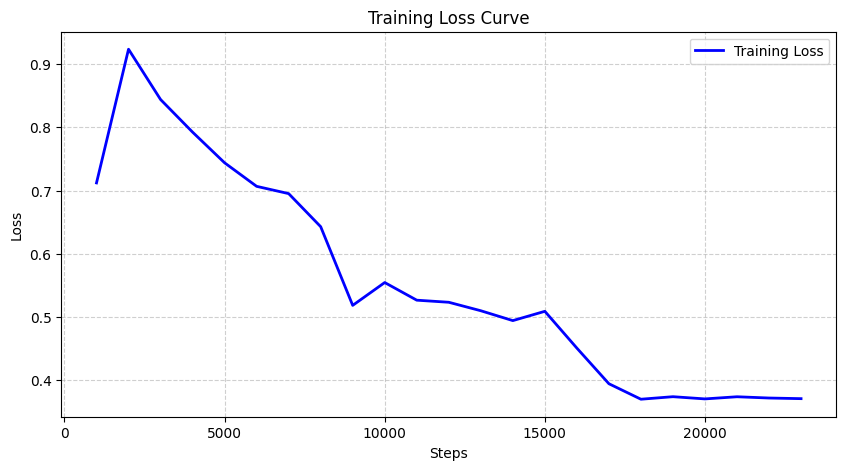

In [ ]:
import matplotlib.pyplot as plt

train_logs = [log for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in train_logs]
losses = [log["loss"] for log in train_logs]

# グラフの描画
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label="Training Loss", color="blue", linewidth=2)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

エラー分析
まずはvalで評価
そこまでよくない気がする

In [27]:
tokenized_eval_dataset = dataset["validation"].map(
    prepare_train_features,
    batched=True,
    remove_columns=dataset["validation"].column_names,
)

Map:   0%|          | 0/4442 [00:00<?, ? examples/s]

In [28]:
eval_results = trainer.evaluate(eval_dataset=tokenized_eval_dataset)

for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

eval_loss: 0.6223
eval_runtime: 18.7596
eval_samples_per_second: 237.2120
eval_steps_per_second: 29.6910
epoch: 3.0000


evalにおいて、誤差が大きい文章を表示

In [ ]:
import pandas as pd
from torch.nn import CrossEntropyLoss
model.eval()
device = trainer.args.device


eval_dataloader = trainer.get_eval_dataloader(eval_dataset=tokenized_eval_dataset)

loss_fct = CrossEntropyLoss(reduction="none")
worst_examples = []

# 検証用データをループで回す
for batch in eval_dataloader:
    # データをデバイスへ転送
    batch = {k: v.to(device) for k, v in batch.items()}
    
    with torch.no_grad():
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        
        start_logits = outputs.start_logits
        end_logits = outputs.end_logits
        
        # 正解インデックス
        true_start = batch["start_positions"]
        true_end = batch["end_positions"]
        
        # サンプルごとのLossを計算
        start_loss = loss_fct(start_logits, true_start)
        end_loss = loss_fct(end_logits, true_end)
        total_loss = (start_loss + end_loss) / 2  
        

        pred_start = torch.argmax(start_logits, dim=1)
        pred_end = torch.argmax(end_logits, dim=1)
        
        for i in range(len(total_loss)):
            worst_examples.append({
                "loss": total_loss[i].item(),
                "input_ids": batch["input_ids"][i].cpu().tolist(),
                "true_start": true_start[i].item(),
                "true_end": true_end[i].item(),
                "pred_start": pred_start[i].item(),
                "pred_end": pred_end[i].item()
            })

df_errors = pd.DataFrame(worst_examples)
df_errors = df_errors.sort_values(by="loss", ascending=False).reset_index(drop=True)

あながち、頓珍漢ではない気がする

In [51]:

for i in range(3):
    row = df_errors.iloc[i]
    print(f"\n【ワースト {i+1} 位】 Loss: {row['loss']:.4f}")
    
    sep_idx = row["input_ids"].index(tokenizer.sep_token_id)
    question_text = tokenizer.decode(row["input_ids"][1:sep_idx]).strip()
    
    true_ans = tokenizer.decode(row["input_ids"][int(row["true_start"]) : int(row["true_end"]) + 1])
    pred_ans = tokenizer.decode(row["input_ids"][int(row["pred_start"]) : int(row["pred_end"]) + 1])
    
    context_text = tokenizer.decode(row["input_ids"][sep_idx+2:], skip_special_tokens=True).strip()
    print(f"■ 質問:     {question_text}")
    print(f"■ 正解:     {true_ans }")
    print(f"■ AIの予測: {pred_ans }")
    print(f"■ 文脈抜粋: {context_text[:100]}...")
    print("-" * 50)


【ワースト 1 位】 Loss: 15.5645
■ 質問:     日本共産党の党大会は党施設内のとある場所にて行われるが、その場所は
■ 正解:     水を抜いたプール
■ AIの予測: 付属大講堂
■ 文脈抜粋: 日本共産党 [SEP] 科学的社会主義や公式党史などを学ぶ「党中央学校」(2014年時点で、党中央学校の「卒業生」は志位和夫委員長はじめ1万人を超える)などが開かれる他、党大会(1977年10月の第1...
--------------------------------------------------

【ワースト 2 位】 Loss: 13.4938
■ 質問:     日本共産党が発行している新聞は?
■ 正解:     しんぶん赤旗
■ AIの予測: 産経新聞
■ 文脈抜粋: 日本共産党 [SEP] 産経新聞は、神奈川県逗子市、川崎市、座間市、福岡県行橋市といった自治体で日本共産党の議員らが「しんぶん赤旗」の勧誘・配布・集金を行っている、と報道している。また、橋下徹大阪市長...
--------------------------------------------------

【ワースト 3 位】 Loss: 13.3901
■ 質問:     アーキテクトとドラフトマンとではどちらが優位であるか
■ 正解:     <s>
■ AIの予測: ドラフトマン
■ 文脈抜粋: 建築家 [SEP] この上で、明治期の日本で近代建槃設計として始められた建築教育は、欧米のアーキテクト教育ではなくドラフトマン教育であったとし、日本では人文科学としての近代ルネサンス思想などを学ぶため...
--------------------------------------------------


ここからは数値による評価

In [ ]:
import torch.nn.functional as F
eval_records = []

model.eval()
eval_dataloader = trainer.get_eval_dataloader(eval_dataset=tokenized_eval_dataset)

for batch in eval_dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        
        # 確信度を出すため、Softmaxで確率(0.0〜1.0)に変換
        start_probs = F.softmax(outputs.start_logits, dim=1)
        end_probs = F.softmax(outputs.end_logits, dim=1)
        
        pred_start = torch.argmax(outputs.start_logits, dim=1)
        pred_end = torch.argmax(outputs.end_logits, dim=1)
        
        true_start = batch["start_positions"]
        true_end = batch["end_positions"]
        
        for i in range(len(true_start)):
            input_ids = batch["input_ids"][i].cpu().tolist()
            sep_idx = input_ids.index(tokenizer.sep_token_id)
            
            # テキストの復元
            question_text = tokenizer.decode(input_ids[1:sep_idx]).strip()
            context_text = tokenizer.decode(input_ids[sep_idx+2:], skip_special_tokens=True).strip()#ここは多少ずれる
            true_ans = tokenizer.decode(input_ids[true_start[i]:true_end[i]+1]).strip()
            pred_ans = tokenizer.decode(input_ids[pred_start[i]:pred_end[i]+1]).strip()
            
            # 確信度 (Confidence Score) ＝ 開始確率 × 終了確率
            conf_score = (start_probs[i, pred_start[i]] * end_probs[i, pred_end[i]]).item()
            
            eval_records.append({
                "question": question_text,
                "context": context_text,
                "true_ans": true_ans,
                "pred_ans": pred_ans,
                "context_len": len(context_text),  # 文脈の文字数
                "ans_len": len(true_ans.replace("<s>", "")), # 正解の文字数
                "confidence": conf_score
            })

df_eval = pd.DataFrame(eval_records)

In [58]:
df_eval.iloc[0,:]

question                                      日本で梅雨がないのは北海道とどこか。
context        梅雨 [SEP] 梅雨(つゆ、ばいう)は、北海道と小笠原諸島を除く日本、朝鮮半島南部、中国の...
true_ans                                                   小笠原諸島
pred_ans                                                   小笠原諸島
context_len                                                  130
ans_len                                                        5
confidence                                              0.995192
EM                                                             1
F1                                                           1.0
Name: 0, dtype: object

EMとF1に関しては大きな乖離がないのでOk

In [ ]:
df_eval["EM"] = (df_eval["true_ans"] == df_eval["pred_ans"]).astype(int)


def calc_f1_japanese(true_text, pred_text):
    # どちらも「答えなし(<s>)」の場合は 1.0 (正解)
    if ("<s>" in true_text or not true_text) and ("<s>" in pred_text or not pred_text):
        return 1.0
    # 片方だけ答えなしの場合は 0.0 (不正解)
    if ("<s>" in true_text or not true_text) or ("<s>" in pred_text or not pred_text):
        return 0.0
        
    true_chars = list(true_text)
    pred_chars = list(pred_text)
    
    # 共通して含まれる文字数をカウント
    common_chars = set(true_chars).intersection(set(pred_chars))
    if not common_chars:
        return 0.0
        
    precision = len(common_chars) / len(pred_chars)
    recall = len(common_chars) / len(true_chars)
    return 2 * (precision * recall) / (precision + recall)

df_eval["F1"] = df_eval.apply(lambda row: calc_f1_japanese(row["true_ans"], row["pred_ans"]), axis=1)

print("=== 評価指標のサマリー ===")
print(f"EM (完全一致率): {df_eval['EM'].mean():.4f}")
print(f"F1 (部分一致率): {df_eval['F1'].mean():.4f}")
print(f"乖離 (F1 - EM) : {df_eval['F1'].mean() - df_eval['EM'].mean():.4f}")

=== 評価指標のサマリー ===
EM (完全一致率): 0.8065
F1 (部分一致率): 0.8612
乖離 (F1 - EM) : 0.0547


答えがないのに、答えを見つけてしまう性質はありそう、ここに改善点はあるかも

In [ ]:
def classify_error(row):
    is_true_empty = "<s>" in row["true_ans"] or not row["true_ans"]
    is_pred_empty = "<s>" in row["pred_ans"] or not row["pred_ans"]
    
    if is_true_empty and is_pred_empty:
        return "TN (正しく『答えなし』と判断)"
    elif not is_true_empty and not is_pred_empty:
        return "TP (何らかの答えを抽出した)"
    elif is_true_empty and not is_pred_empty:
        return "FP (過剰反応: 答えがないのに抽出)"
    else:
        return "FN (見逃し: 答えがあるのに『答えなし』)"

df_eval["error_type"] = df_eval.apply(classify_error, axis=1)

print(df_eval["error_type"].value_counts())


=== エラーパターン (FP/FN) の分布 ===
error_type
TP (何らかの答えを抽出した)           4420
FN (見逃し: 答えがあるのに『答えなし』)      20
FP (過剰反応: 答えがないのに抽出)          6
TN (正しく『答えなし』と判断)             4
Name: count, dtype: int64


文章量によって、正誤の違いはあるのか

/tmp/ipykernel_64653/4272985413.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval, x="context_len_bin", y="F1", palette="Blues_d")


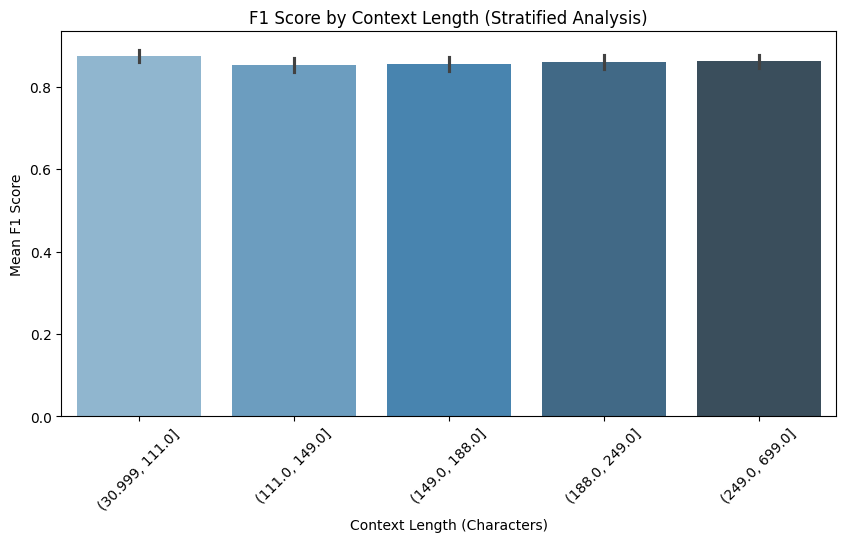

In [60]:
df_eval["context_len_bin"] = pd.qcut(df_eval["context_len"], q=5, duplicates="drop")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_eval, x="context_len_bin", y="F1", palette="Blues_d")
plt.title("F1 Score by Context Length (Stratified Analysis)")
plt.xlabel("Context Length (Characters)")
plt.ylabel("Mean F1 Score")
plt.xticks(rotation=45)
plt.show()

自信によって、正解率は違うのかのcheck,とくに差異はなし

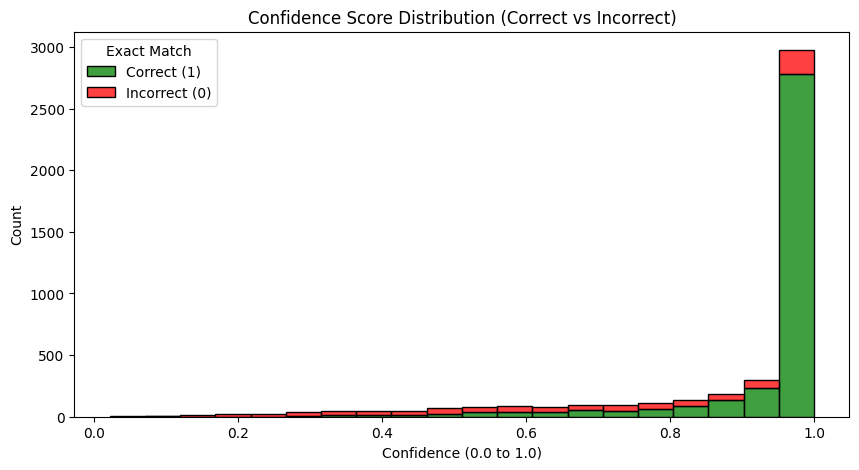

In [61]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_eval, 
    x="confidence", 
    hue="EM", 
    multiple="stack", 
    bins=20, 
    palette={1: "green", 0: "red"}
)
plt.title("Confidence Score Distribution (Correct vs Incorrect)")
plt.xlabel("Confidence (0.0 to 1.0)")
plt.ylabel("Count")
plt.legend(title="Exact Match", labels=["Correct (1)", "Incorrect (0)"])
plt.show()